In [1]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import scanpy as sc
from spatialtools.annotation import (
    annotate,
)

from spatial_tcr.tcr import aggregate_trv_expression, get_tcr_genes

Changed working directory to /bonn-epyc/projects/dschaub/analysis-projects/spatial-tcr


In [2]:
adata = sc.read_h5ad("data/xenium/processed/02-kidney_tcr_split.h5ad")
adata, adata.X.max()

(AnnData object with n_obs × n_vars = 510159 × 480
     obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc'
     var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
     uns: 'graph'
     obsm: 'spatial'
     layers: 'counts',
 np.float32(136.0))

## prep training data

In [3]:
ad_ref = sc.read(
    "/bonn-epyc/projects/robin/singlecell/kidney/Lake/cellxgene_obj.h5ad"
).raw.to_adata()
ad_ref.var["feature_name"] = ad_ref.var["feature_name"].astype(str)
ad_ref.var = ad_ref.var.set_index("feature_name")
ad_ref

AnnData object with n_obs × n_vars = 304652 × 33920
    obs: 'nCount_RNA', 'nFeature_RNA', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'experiment', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'donor_id', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'tissue_type', 'id', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'disease_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'eGFR', 'BMI', 'diabetes_history', 'hypertension', 'tissue_ontology_term_id', 'organism_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'sel

In [4]:
ad_ref.X.max()

np.float32(27935.0)

## Prepare annotations

In [5]:
ad_ref.obs["subclass.l1"].unique().tolist()

['PT',
 'FIB',
 'TAL',
 'IMM',
 'IC',
 'EC',
 'DTL',
 'POD',
 'ATL',
 'PC',
 'CNT',
 'DCT',
 'VSM/P',
 'NEU',
 'PEC',
 'PapE']

In [6]:
ad_ref.obs["cell_type_new"] = ad_ref.obs["subclass.l1"].astype(str).copy()
mask_immune = ad_ref.obs["cell_type_new"] == "IMM"
ad_ref.obs.loc[mask_immune, "cell_type_new"] = ad_ref.obs.loc[
    mask_immune, "subclass.l2"
]
mask_corpuscle = ad_ref.obs["structure"] == "renal corpuscle"
ad_ref.obs.loc[mask_corpuscle, "cell_type_new"] = ad_ref.obs.loc[
    mask_corpuscle, "subclass.l2"
].astype(str)

# Define the mapping dictionary
ct_map = {
    "dPOD": "podocyte",
    "POD": "podocyte",
    "EC-GC": "glomerular endothelial cell",
    "MC": "mesangial cell",
    "PEC": "parietal epithelial cell",
    # "glomerular endothelial cell": "endothelial cell",
    "MAC-M2": "Mac",
    "ncMON": "Mac",
}


ct_map = {
    "dPOD": "POD",
    "EC-GC": "glom. EC",
    "glomerular endothelial cell": "glom. EC",
    "MAC-M2": "Mac",
    "ncMON": "Mac",
    "cycNKC/T": "T",
    "NKC/T": "T",
}

ad_ref.obs["cell_type_new"] = ad_ref.obs["cell_type_new"].replace(ct_map)

In [7]:
ad_ref.obs.cell_type_new.value_counts()

cell_type_new
PT          76031
TAL         66257
PC          23239
EC          21411
IC          18001
FIB         16548
CNT         13245
DCT         13216
T           11484
DTL          9786
VSM/P        6249
Mac          5968
MDC          4441
glom. EC     3764
ATL          3384
POD          2832
PEC          2417
B            2194
PL           1353
N             860
PapE          531
MC            458
MAST          400
cDC           216
cycMNP        215
NEU            77
pDC            75
Name: count, dtype: int64

In [8]:
# check tcr
ad_tmp = aggregate_trv_expression(ad_ref)

Found 31 TRAV genes, 20 TRBV genes, 1 TRDV genes, 10 TRGV genes


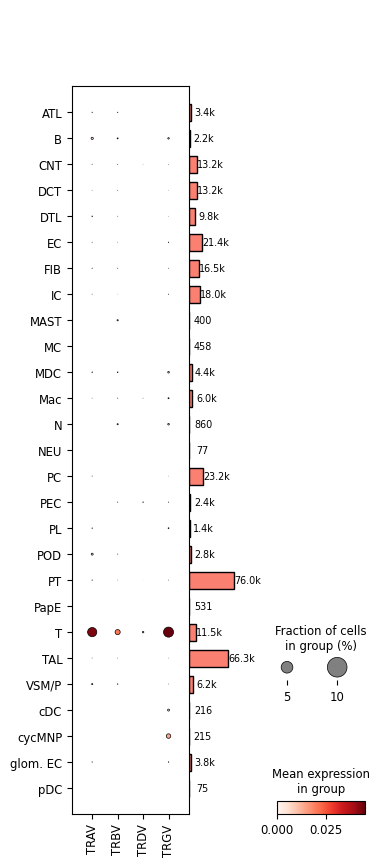

In [9]:
markers = ["TRAV", "TRBV", "TRDV", "TRGV"]

dp = sc.pl.dotplot(
    ad_tmp,
    markers,
    groupby="cell_type_new",
    return_fig=True,
    # standard_scale="var",
    cmap="Reds",
)
dp.add_totals().style(dot_edge_color="black", dot_edge_lw=0.5).show()

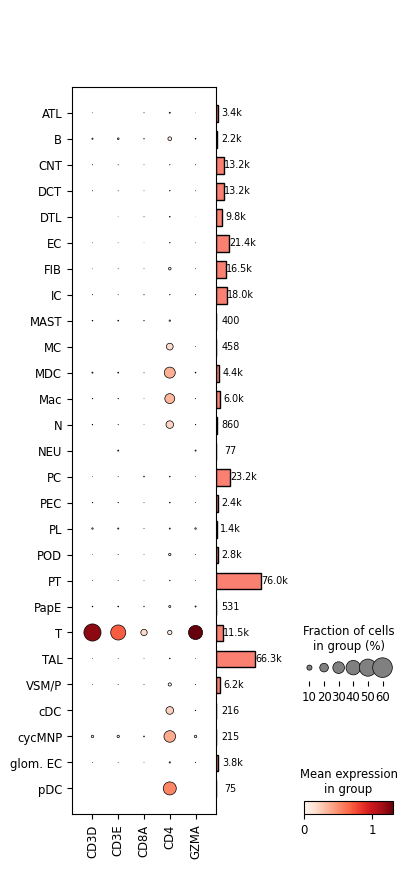

In [10]:
markers = ["CD3D", "CD3E", "CD8A", "CD4", "GZMA"]
dp = sc.pl.dotplot(
    ad_ref,
    groupby="cell_type_new",
    var_names=markers,
    return_fig=True,
    dendrogram=False,
)
dp.add_totals().style(dot_edge_color="black", dot_edge_lw=0.5).show()

In [11]:
ad_ref.obs["cell_type"] = ad_ref.obs["cell_type"].str.replace("kidney", "").str.strip()

## Annotation transfer without tcr genes

In [12]:
common_genes = ad_ref.var_names.intersection(adata.var_names)

av_genes, bv_genes, dv_genes, gv_genes, tv_genes = get_tcr_genes(adata)

common_genes = [g for g in common_genes if g not in tv_genes]
len(common_genes)

Found 54 TRAV genes, 61 TRBV genes, 3 TRDV genes, 14 TRGV genes


343

In [13]:
annotate(
    adata,
    ad_ref,
    label_key="cell_type_new",
    label_out="cell_type_no_tcr",
    genes=common_genes,
)

Fitting the model ...
Model fitted.


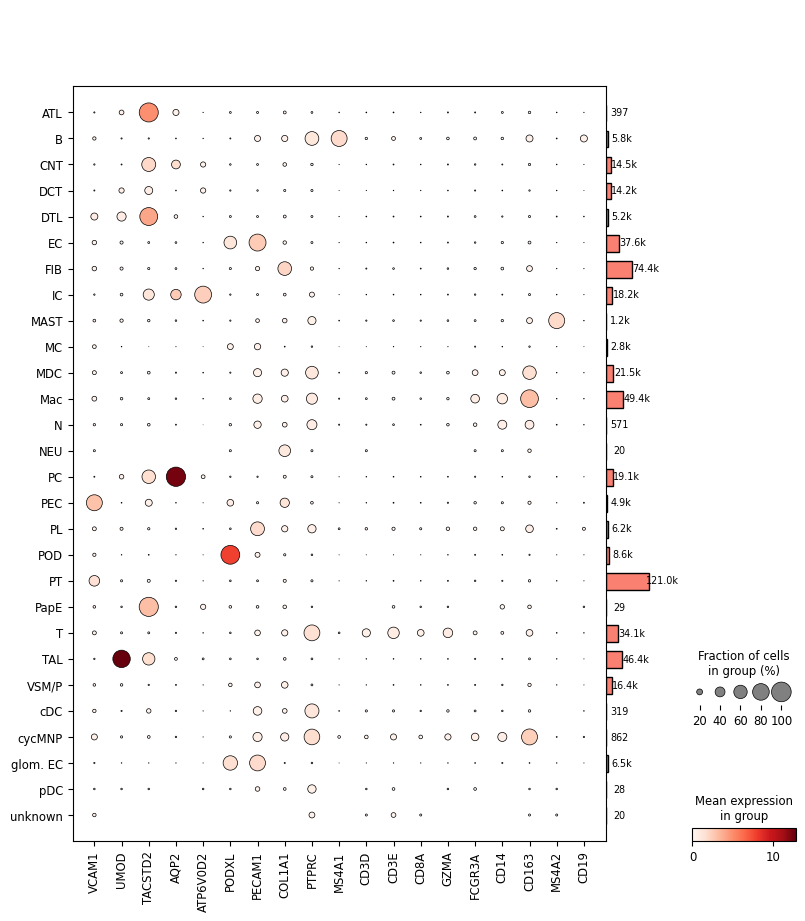

In [14]:
markers = [
    # "LRP2",
    "VCAM1",
    # "CLDN1",
    "UMOD",
    "TACSTD2",
    # "SLC12A3",
    # "CALB1",
    "AQP2",
    "ATP6V0D2",
    # "NRXN1",
    "PODXL",
    "PECAM1",
    # "PDGFRB",
    "COL1A1",
    "PTPRC",
    "MS4A1",
    "CD3D",
    "CD3E",
    "CD8A",
    "GZMA",
    "FCGR3A",
    "CD14",
    "CD163",
    # "CLEC4C",
    # "ITGAX",
    # "CLEC9A",
    # "S100A9",
    "MS4A2",
    "CD19",
]
dp = sc.pl.dotplot(
    adata,
    groupby="cell_type_no_tcr",
    var_names=markers,
    return_fig=True,
    dendrogram=False,
)
dp.add_totals().style(dot_edge_color="black", dot_edge_lw=0.5).show()

<Axes: >

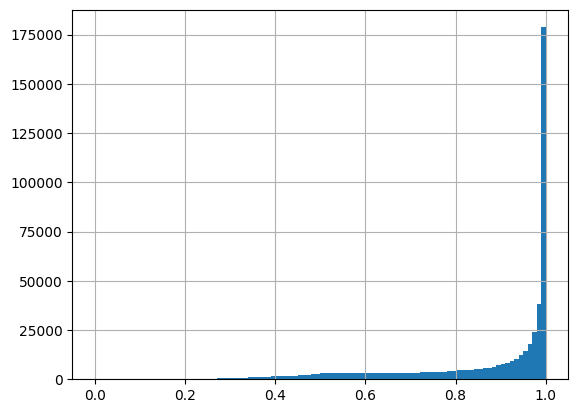

In [15]:
adata.obs.cell_type_no_tcr_prob.hist(bins=100)

In [16]:
# require 75% probability
mask = adata.obs.cell_type_no_tcr_prob > 0.50
ad_bad = adata[~mask].copy()
ad_bad.obs["cell_type_no_tcr"].value_counts()

cell_type_no_tcr
FIB         4714
Mac         4008
PT          3261
MDC         3018
TAL         2695
T           2154
VSM/P       2071
CNT         2057
EC          1888
DCT         1049
DTL          955
PC           705
IC           675
MC           638
PL           551
B            480
PEC          449
POD          313
glom. EC     311
cycMNP       275
N            230
ATL          153
MAST         111
cDC           76
unknown       20
PapE          20
pDC           16
NEU           10
Name: count, dtype: int64

In [17]:
# remove unknown cells
adata = adata[adata.obs.cell_type_no_tcr != "unknown"].copy()
adata.obs["cell_type_no_tcr"].value_counts()

cell_type_no_tcr
PT          120967
FIB          74374
Mac          49430
TAL          46435
EC           37587
T            34054
MDC          21481
PC           19083
IC           18175
VSM/P        16376
CNT          14532
DCT          14170
POD           8579
glom. EC      6541
PL            6244
B             5833
DTL           5179
PEC           4894
MC            2810
MAST          1169
cycMNP         862
N              571
ATL            397
cDC            319
PapE            29
pDC             28
NEU             20
Name: count, dtype: int64

In [18]:
adata

AnnData object with n_obs × n_vars = 510139 × 480
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'graph'
    obsm: 'spatial', 'cell_type_no_tcr_probs'
    layers: 'counts'

In [19]:
adata.write_h5ad("data/xenium/processed/03-kidney_tcr_classified.h5ad")

/home/dschaub/.uv-local/venvs/spatial-tcr/lib/python3.13/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)
